# Домашная работа №2: Детектирование приступа эпилепсии по данным ЭЭГ

**Студент:** Сизиков Константин.

**Задача:** бинарная классификация односекундных фрагментов электроэнцефалограммы — приступ (класс 1) против всех остальных состояний.

ЭЭГ регистрирует электрическую активность мозга. Эпилептический приступ сопровождается аномальной — гиперсинхронной и высокоамплитудной — активностью, которую можно детектировать по сигналу.

**План работы:**

1. Загрузка данных и EDA, перевод целевой переменной в бинарную.
2. Стратифицированное разбиение 80/20.
3. Бейзлайн на сырых отсчётах сигнала (178 признаков, без предобработки).
4. Признаки из частотной области: **FFT** (спектральные полосы, энтропия, спектральные моменты).
5. Признаки вейвлет-разложения: **DWT (db4)** — статистики по субполосам.
6. Автоматическая генерация статистических признаков временных рядов — **tsfresh**.
7. Сравнение качества, выводы.

**Данные:** `data/Epileptic_Seizure_Recognition.csv` — 11500 фрагментов по 178 отсчётов (1 секунда записи, частота дискретизации 178 Гц).

Исходные 5 классов:

| Класс | Описание |
|---|---|
| 1 | Регистрация во время эпилептического приступа |
| 2 | Запись с области опухоли |
| 3 | Здоровая область мозга у пациента с опухолью |
| 4 | Здоровый пациент, глаза закрыты |
| 5 | Здоровый пациент, глаза открыты |

Классы 2–5 — отсутствие приступа, поэтому целевая переменная формируется как `y_bin = (y == 1)`.

In [1]:
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import pywt

from scipy.stats import skew, kurtosis
from scipy.signal import welch

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_predict,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, precision_score,
    recall_score, accuracy_score, balanced_accuracy_score,
    precision_recall_curve, roc_curve, confusion_matrix, classification_report,
)
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")

SEED = 42
FS = 178          # частота дискретизации, Гц (178 отсчётов за 1 секунду)
N_JOBS = -1
DATA_PATH = os.path.join("data", "Epileptic_Seizure_Recognition.csv")

np.random.seed(SEED)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

print("numpy", np.__version__, "| pandas", pd.__version__, "| pywt", pywt.__version__)

numpy 2.4.6 | pandas 3.0.5 | pywt 1.8.0


In [2]:
%matplotlib inline

# Палитра: категориальные слоты назначаются в фиксированном порядке (не циклически).
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4",
           "#008300", "#4a3aa7", "#e34948"]
SURFACE   = "#fcfcfb"
INK       = "#0b0b0b"   # основной текст
INK_2     = "#52514e"   # вторичный текст
INK_MUTED = "#8a8984"   # подписи осей
GRID      = "#e5e4e0"   # рецессивная сетка

mpl.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK_2,
    "axes.titlecolor": INK,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.titlepad": 10,
    "axes.labelsize": 10,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "text.color": INK,
    "legend.frameon": False,
    "legend.fontsize": 9,
    "lines.linewidth": 2.0,
    "figure.dpi": 110,
})

def tidy(ax, xgrid=False):
    # Убираем лишние рамки, оставляем только нужную сетку.
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.spines["left"].set_color(GRID)
    ax.spines["bottom"].set_color(GRID)
    ax.grid(axis="x" if xgrid else "y")
    if xgrid:
        ax.grid(axis="y", visible=False)
    return ax

## 1. Загрузка данных

In [3]:
df = pd.read_csv(DATA_PATH)
print("Размер таблицы:", df.shape)
df.head()

Размер таблицы: (11500, 180)


,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,X24,X25,X26,X27,X28,X29,...,X150,X151,X152,X153,X154,X155,X156,X157,X158,X159,X160,X161,X162,X163,X164,X165,X166,X167,X168,X169,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,-38,-10,35,64,113,152,164,127,50,-47,-121,-138,-125,-101,-50,11,39,24,48,64,...,-44,-33,-57,-88,-114,-130,-114,-83,-53,-79,-72,-85,-109,-98,-72,-65,-63,-11,10,8,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,232,237,258,212,2,-267,-605,-850,-1001,-1109,-1090,-967,-746,-464,-152,118,318,427,473,485,...,280,231,159,85,51,43,62,63,63,69,89,123,136,127,102,95,105,131,163,168,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,-94,-99,-94,-96,-104,-103,-92,-75,-69,-69,-53,-37,-14,-10,-39,-78,-102,-98,-80,-54,...,-62,-33,1,28,45,37,48,62,80,66,23,-11,-39,-44,-42,-45,-48,-42,-6,29,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,-79,-72,-68,-74,-80,-83,-73,-68,-61,-58,-59,-64,-79,-84,-97,-94,-84,-77,-75,-72,...,-64,-78,-80,-90,-87,-83,-78,-64,-38,-22,-29,-42,-51,-68,-71,-69,-69,-74,-74,-80,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,-59,-90,-103,-84,-43,-9,3,-21,-60,-96,-103,-75,-29,14,55,78,73,28,-13,-43,...,57,63,45,7,-13,-23,-9,9,11,3,-1,-2,4,18,27,27,14,15,11,10,4,2,-12,-32,-41,-65,-83,-89,-73,5


In [4]:
signal_cols = [c for c in df.columns if c.startswith("X")]
print("Колонок с отсчётами сигнала:", len(signal_cols))
print("Служебные колонки:", [c for c in df.columns if c not in signal_cols])

print("\nТипы данных:", df[signal_cols].dtypes.unique().tolist())
print("Пропусков всего:", int(df.isna().sum().sum()))
print("Полных дубликатов строк:", int(df.duplicated().sum()))
print("Дубликатов идентификатора:", int(df["Unnamed"].duplicated().sum()))
print("\nДиапазон амплитуд: [{}, {}]".format(df[signal_cols].to_numpy().min(),
                                             df[signal_cols].to_numpy().max()))

Колонок с отсчётами сигнала: 178
Служебные колонки: ['Unnamed', 'y']

Типы данных: [dtype('int64')]
Пропусков всего: 0
Полных дубликатов строк: 0
Дубликатов идентификатора: 0

Диапазон амплитуд: [-1885, 2047]


Пропусков и дубликатов нет, все отсчёты — целые числа (микровольты ЭЭГ), масштаб признаков одинаковый по построению.

### 1.1. Структура идентификаторов

Колонка `Unnamed` имеет вид `X{номер_фрагмента}.V{версия}.{номер_записи}`. Разберём её — это важно для понимания, насколько независимы строки выборки.

In [5]:
ids = df["Unnamed"]
# Идентификатор записи = всё после первой точки; первый токен — номер односекундного фрагмента.
recording = ids.str.split(".", n=1).str[1]
chunk = ids.str.split(".", n=1).str[0]

print("Уникальных записей (пациент/сеанс):", recording.nunique())
print("Уникальных номеров фрагментов:", chunk.nunique())
print("Фрагментов на запись:", df.groupby(recording).size().value_counts().to_dict())
print("Различных классов внутри одной записи:",
      df.groupby(recording)["y"].nunique().value_counts().to_dict())
print("\nЗаписей по классам:")
print(df.groupby(recording)["y"].first().value_counts().sort_index())

Уникальных записей (пациент/сеанс): 500
Уникальных номеров фрагментов: 23
Фрагментов на запись: {23: 500}
Различных классов внутри одной записи: {1: 500}

Записей по классам:
y
1    100
2    100
3    100
4    100
5    100
Name: count, dtype: int64


> **Важное наблюдение.** Набор данных состоит из **500 записей**, каждая нарезана на 23 односекундных фрагмента (23 × 178 отсчётов ≈ 23 секунды записи). Все 23 фрагмента одной записи принадлежат одному классу и одному пациенту, то есть строки выборки **не независимы**.
>
> Стандартное случайное разбиение (которое требуется по заданию) раскидывает фрагменты одной записи и в train, и в test — модель в принципе может «узнавать пациента», а не приступ. Основной протокол делаем как в задании, а в разделе 10 отдельно проверим, как это влияет на оценку, с помощью разбиения по записям.

## 2. EDA

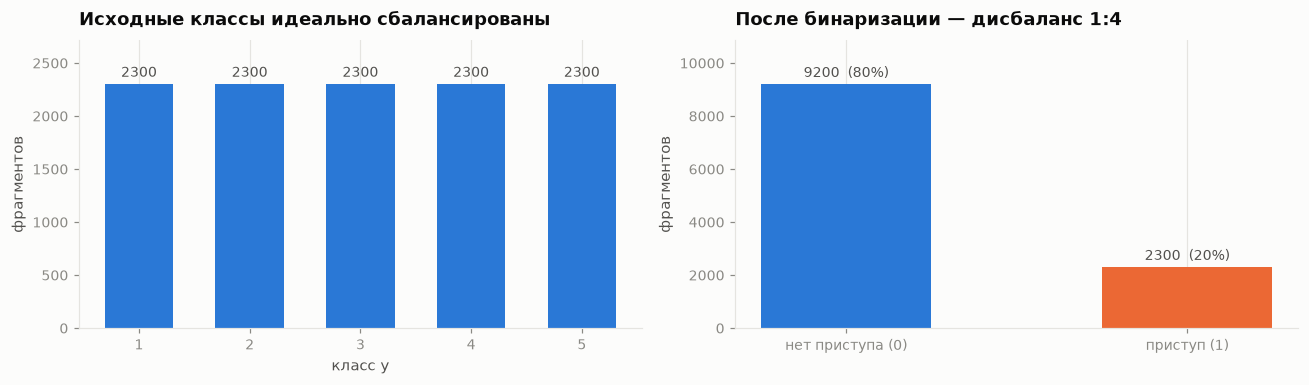

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))

# Слева — исходные 5 классов, справа — бинарная постановка.
vc = df["y"].value_counts().sort_index()
ax = tidy(axes[0])
ax.bar(vc.index.astype(str), vc.values, color=PALETTE[0], width=0.62)
for x, v in zip(range(len(vc)), vc.values):
    ax.text(x, v + 40, str(v), ha="center", va="bottom", fontsize=9, color=INK_2)
ax.set_title("Исходные классы идеально сбалансированы")
ax.set_xlabel("класс y"); ax.set_ylabel("фрагментов")
ax.set_ylim(0, vc.max() * 1.18)

y_bin_all = (df["y"] == 1).astype(int)
vb = y_bin_all.value_counts().sort_index()
ax = tidy(axes[1])
ax.bar(["нет приступа (0)", "приступ (1)"], vb.values, color=[PALETTE[0], PALETTE[1]], width=0.5)
for x, v in zip(range(2), vb.values):
    ax.text(x, v + 150, f"{v}  ({v / len(df):.0%})", ha="center", va="bottom", fontsize=9, color=INK_2)
ax.set_title("После бинаризации — дисбаланс 1:4")
ax.set_ylabel("фрагментов")
ax.set_ylim(0, vb.max() * 1.18)

plt.tight_layout(); plt.show()

Исходные классы сбалансированы (по 2300). После склейки 2–5 в «нет приступа» получаем соотношение **20% / 80%** — умеренный дисбаланс. Отсюда два следствия для метрик:

* accuracy неинформативна (константный прогноз «нет приступа» даёт 80%);
* основные метрики — **ROC-AUC**, **PR-AUC (average precision)** и **F1** по положительному классу, плюс recall — в медицинской задаче пропуск приступа дороже ложной тревоги.

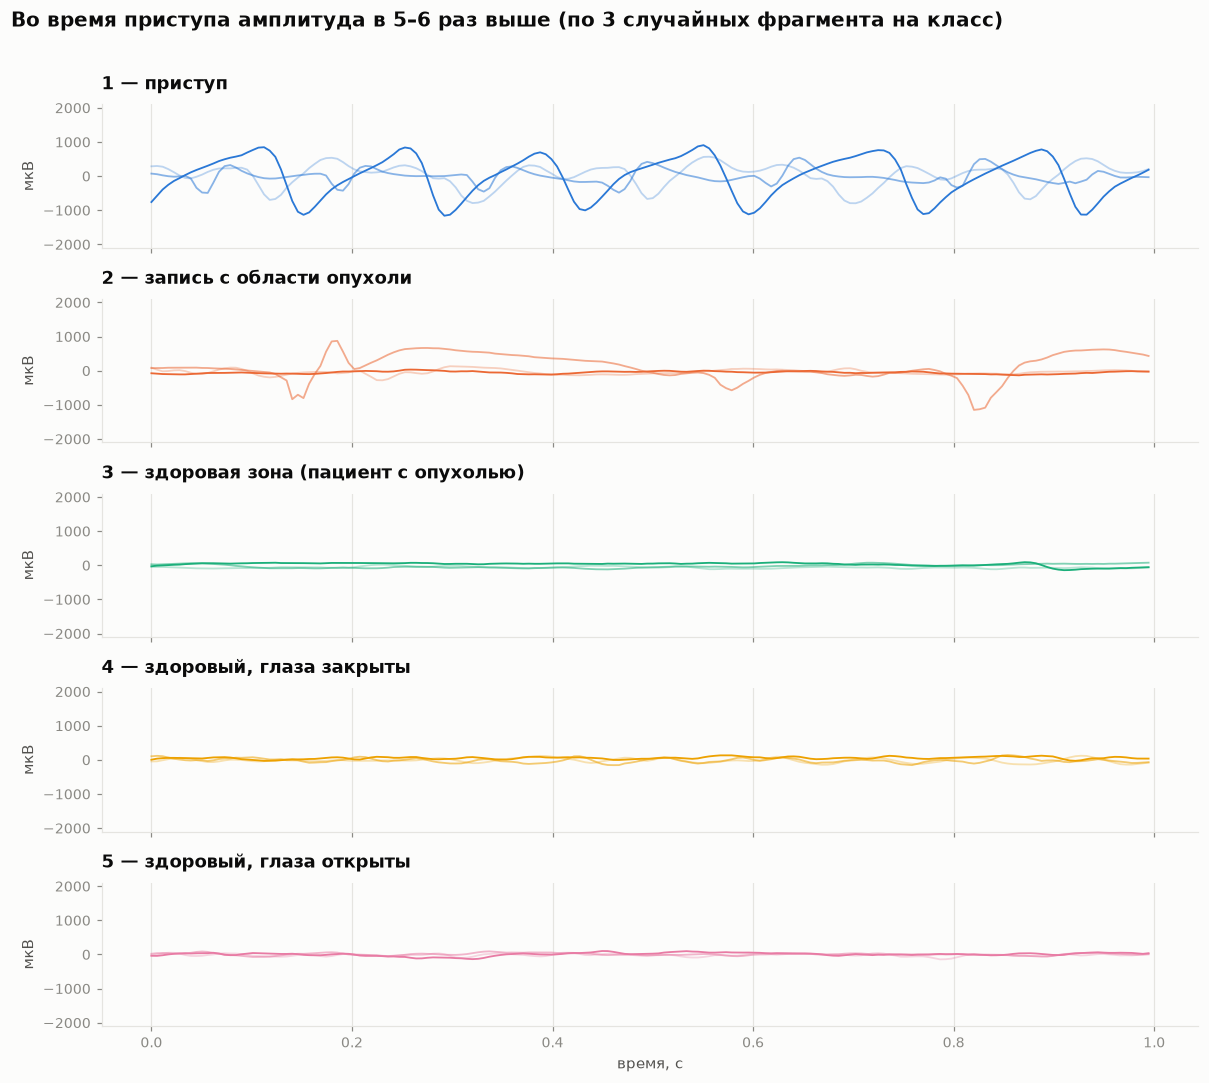

In [7]:
# Как выглядит сигнал в каждом из пяти исходных состояний.
titles = {
    1: "1 — приступ",
    2: "2 — запись с области опухоли",
    3: "3 — здоровая зона (пациент с опухолью)",
    4: "4 — здоровый, глаза закрыты",
    5: "5 — здоровый, глаза открыты",
}
t = np.arange(178) / FS

fig, axes = plt.subplots(5, 1, figsize=(11, 10), sharex=True)
for i, cls in enumerate(sorted(df["y"].unique())):
    sub = df[df["y"] == cls].sample(3, random_state=SEED)
    ax = tidy(axes[i])
    for j, (_, row) in enumerate(sub.iterrows()):
        ax.plot(t, row[signal_cols].to_numpy(dtype=float),
                color=PALETTE[i], alpha=[1.0, 0.55, 0.3][j], linewidth=1.2)
    ax.set_title(titles[cls])
    ax.set_ylabel("мкВ")
    ax.set_ylim(-2100, 2100)
axes[-1].set_xlabel("время, с")
fig.suptitle("Во время приступа амплитуда в 5–6 раз выше (по 3 случайных фрагмента на класс)",
             x=0.005, ha="left", fontsize=13, fontweight="bold", color=INK)
plt.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()

Видно главное различие: во время приступа амплитуда сигнала заметно выше, колебания крупные и более «синхронные». Классы 2–5 визуально похожи друг на друга и редко выходят за ±200 мкВ.

Проверим это количественно — через амплитудные статистики.

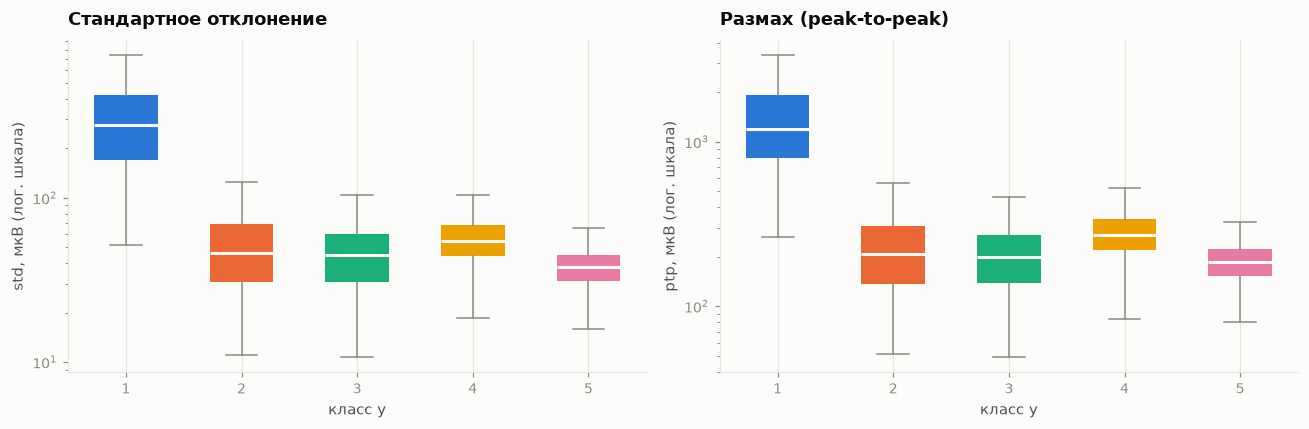

         std     ptp
class               
1      277.4  1194.0
2       45.9   206.5
3       44.8   199.0
4       54.5   269.0
5       38.1   186.0


In [8]:
amp = pd.DataFrame({
    "class": df["y"],
    "std": df[signal_cols].std(axis=1),
    "ptp": df[signal_cols].max(axis=1) - df[signal_cols].min(axis=1),
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, name in zip(axes, ["std", "ptp"],
                         ["Стандартное отклонение", "Размах (peak-to-peak)"]):
    tidy(ax)
    data = [amp.loc[amp["class"] == c, col].to_numpy() for c in sorted(amp["class"].unique())]
    bp = ax.boxplot(data, patch_artist=True, widths=0.55, showfliers=False,
                    medianprops=dict(color=SURFACE, linewidth=2),
                    whiskerprops=dict(color=INK_MUTED, linewidth=1),
                    capprops=dict(color=INK_MUTED, linewidth=1),
                    boxprops=dict(linewidth=0))
    for patch, color in zip(bp["boxes"], PALETTE[:5]):
        patch.set_facecolor(color)
    ax.set_yscale("log")
    ax.set_xticklabels([str(c) for c in sorted(amp["class"].unique())])
    ax.set_xlabel("класс y"); ax.set_ylabel(f"{col}, мкВ (лог. шкала)")
    ax.set_title(name)
plt.tight_layout(); plt.show()

print(amp.groupby("class")[["std", "ptp"]].median().round(1))

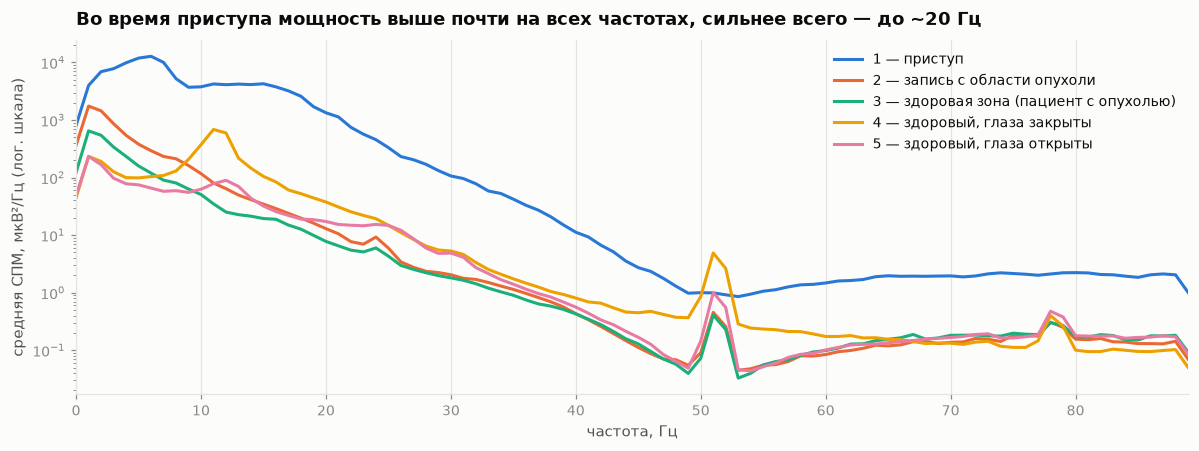

In [9]:
# Средний спектр мощности по классам (метод Уэлча).
fig, ax = plt.subplots(figsize=(11, 4.2))
tidy(ax)
for i, cls in enumerate(sorted(df["y"].unique())):
    sig = df.loc[df["y"] == cls, signal_cols].to_numpy(dtype=float)
    f, pxx = welch(sig, fs=FS, nperseg=178, axis=1)
    ax.semilogy(f, pxx.mean(axis=0), color=PALETTE[i], label=titles[cls])
ax.set_xlabel("частота, Гц"); ax.set_ylabel("средняя СПМ, мкВ²/Гц (лог. шкала)")
ax.set_title("Во время приступа мощность выше почти на всех частотах, сильнее всего — до ~20 Гц")
ax.set_xlim(0, FS / 2)
ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

Спектральная картина подтверждает: у класса «приступ» мощность выше почти на всех частотах (в среднем в 40 раз ниже 10 Гц и в 15 раз выше 30 Гц). Абсолютная мощность — самый сильный одиночный сигнал в данных.

Попутно график подтверждает, что перед нами настоящая ЭЭГ, а не случайный шум:

* у класса 4 (здоровый, **глаза закрыты**) виден выраженный пик около 11 Гц — это классический **альфа-ритм**, он в 8.6 раза выше соседних частот. У класса 5 (те же люди, но **глаза открыты**) пик почти пропадает (всего в 2.2 раза) — известный эффект блокады альфа-ритма при открывании глаз;
* у всех классов заметен провал в районе 50 Гц — след режекторного фильтра сетевой наводки.

**Вывод по EDA:** данные чистые, шкала однородная, приступ хорошо отделим по амплитудно-частотным характеристикам. Это уже подсказывает, что спектральные признаки должны работать лучше сырых отсчётов.

## 3. Бинарная целевая переменная и разбиение train/test

In [10]:
X_raw = df[signal_cols].to_numpy(dtype=np.float64)
y = (df["y"] == 1).astype(int).to_numpy()
groups = recording.to_numpy()          # понадобится в разделе 10

idx = np.arange(len(df))
idx_tr, idx_te = train_test_split(
    idx, test_size=0.2, stratify=y, random_state=SEED, shuffle=True
)
y_tr, y_te = y[idx_tr], y[idx_te]

print(f"train: {len(idx_tr)} фрагментов, доля приступов {y_tr.mean():.4f}")
print(f"test:  {len(idx_te)} фрагментов, доля приступов {y_te.mean():.4f}")

# Единая схема кросс-валидации для всех экспериментов.
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

train: 9200 фрагментов, доля приступов 0.2000
test:  2300 фрагментов, доля приступов 0.2000


Стратификация сохранила долю положительного класса (20%) в обеих частях. Тестовые 20% (2300 фрагментов) откладываем и используем только для финальной оценки; отбор признаков и подбор порога делаем строго по train.

## 4. Протокол оценки моделей

Чтобы сравнение наборов признаков было честным, зафиксируем один протокол для всех экспериментов:

* три модели разной природы — **логистическая регрессия** (линейная, со стандартизацией), **Random Forest** и **LightGBM** (градиентный бустинг);
* гиперпараметры фиксированы и одинаковы во всех экспериментах — меняются только признаки;
* на train считаем out-of-fold прогнозы 5-фолдовой стратифицированной кросс-валидацией: по ним оцениваем стабильность и **подбираем порог, максимизирующий F1** (порог 0.5 при дисбалансе классов не оптимален);
* модель, обученная на всём train, оценивается на отложенном test с этим порогом.

In [11]:
def make_models():
    # Один и тот же набор моделей для каждого эксперимента.
    return {
        "LogReg": make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=3000, C=1.0, random_state=SEED),
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=300, min_samples_leaf=1, n_jobs=N_JOBS, random_state=SEED,
        ),
        "LightGBM": LGBMClassifier(
            n_estimators=400, learning_rate=0.05, num_leaves=31,
            subsample=0.9, subsample_freq=1, colsample_bytree=0.8,
            n_jobs=N_JOBS, random_state=SEED, verbose=-1,
        ),
    }


def best_f1_threshold(y_true, proba):
    # Порог, максимизирующий F1 по out-of-fold прогнозам.
    prec, rec, thr = precision_recall_curve(y_true, proba)
    f1 = 2 * prec * rec / np.maximum(prec + rec, 1e-12)
    return float(thr[int(np.nanargmax(f1[:-1]))])


RESULTS = []      # строки итоговой таблицы
PREDS = {}        # (набор признаков, модель) -> вероятности на test
MODELS = {}       # обученные модели для анализа важностей


def run_experiment(fs_name, Xtr, Xte, feature_names=None, verbose=True):
    # Xtr/Xte — numpy-массивы; имена признаков храним отдельно (в них бывают спецсимволы).
    if verbose:
        print(f"=== {fs_name} | признаков: {Xtr.shape[1]} ===")
    for mname, model in make_models().items():
        t0 = time.time()
        oof = cross_val_predict(model, Xtr, y_tr, cv=CV,
                                method="predict_proba", n_jobs=1)[:, 1]
        thr = best_f1_threshold(y_tr, oof)

        model.fit(Xtr, y_tr)
        proba = model.predict_proba(Xte)[:, 1]
        pred = (proba >= thr).astype(int)
        elapsed = time.time() - t0

        RESULTS.append({
            "Признаки": fs_name,
            "Модель": mname,
            "n_features": Xtr.shape[1],
            "CV ROC-AUC": roc_auc_score(y_tr, oof),
            "CV PR-AUC": average_precision_score(y_tr, oof),
            "CV F1": f1_score(y_tr, (oof >= thr).astype(int)),
            "ROC-AUC": roc_auc_score(y_te, proba),
            "PR-AUC": average_precision_score(y_te, proba),
            "F1": f1_score(y_te, pred),
            "Precision": precision_score(y_te, pred),
            "Recall": recall_score(y_te, pred),
            "Accuracy": accuracy_score(y_te, pred),
            "BalAcc": balanced_accuracy_score(y_te, pred),
            "F1@0.5": f1_score(y_te, (proba >= 0.5).astype(int)),
            "thr": thr,
            "sec": elapsed,
        })
        PREDS[(fs_name, mname)] = proba
        MODELS[(fs_name, mname)] = (model, feature_names)
        if verbose:
            r = RESULTS[-1]
            print(f"  {mname:13s} ROC-AUC={r['ROC-AUC']:.4f}  PR-AUC={r['PR-AUC']:.4f}  "
                  f"F1={r['F1']:.4f}  Recall={r['Recall']:.4f}  ({elapsed:.0f} c)")


def results_table(sort_by="F1"):
    cols = ["Признаки", "Модель", "n_features", "CV ROC-AUC", "CV F1",
            "ROC-AUC", "PR-AUC", "F1", "Precision", "Recall", "BalAcc"]
    return (pd.DataFrame(RESULTS)[cols]
            .sort_values(sort_by, ascending=False)
            .reset_index(drop=True)
            .round(4))

## 5. Baseline: сырые отсчёты сигнала

Подаём 178 значений сигнала как есть, без какой-либо предобработки. Это честный бейзлайн: признак `X37` означает «амплитуда на 37-м отсчёте», и физического смысла в сравнении одного и того же отсчёта у разных фрагментов нет — фаза сигнала произвольна.

In [12]:
run_experiment("Сырой сигнал (178)", X_raw[idx_tr], X_raw[idx_te],
               feature_names=signal_cols)

=== Сырой сигнал (178) | признаков: 178 ===


  LogReg        ROC-AUC=0.4993  PR-AUC=0.4310  F1=0.4209  Recall=0.3065  (66 c)


  RandomForest  ROC-AUC=0.9966  PR-AUC=0.9874  F1=0.9467  Recall=0.9457  (15 c)


  LightGBM      ROC-AUC=0.9973  PR-AUC=0.9898  F1=0.9540  Recall=0.9478  (6 c)


**Что мы видим.** Деревья (RF и LightGBM) справляются отлично, а логистическая регрессия проваливается — ROC-AUC около 0.5, то есть на уровне случайного угадывания.

Причина в природе признаков: линейная модель ищет взвешенную сумму отсчётов, но сигнал не выровнен по фазе, и его среднее значение около нуля в обоих классах — любая линейная комбинация отсчётов почти не разделяет классы. Деревья же режут по порогам и фактически восстанавливают «есть ли хоть где-то большая амплитуда», то есть нелинейно вытаскивают дисперсию сигнала.

Это ключевой аргумент в пользу извлечения признаков: нужно перейти от «сигнала по времени» к характеристикам, инвариантным к сдвигу фазы.

## 6. Признаки частотной области (FFT)

Каждый фрагмент — это сигнал длиной 178 отсчётов при частоте дискретизации 178 Гц, значит доступен диапазон частот до 89 Гц (частота Найквиста), а шаг по частоте равен 1 Гц.

Считаем быстрое преобразование Фурье (с окном Ханна, чтобы уменьшить растекание спектра) и извлекаем из спектра мощности:

* **мощность в клинических ритмах ЭЭГ** — дельта (0.5–4 Гц), тета (4–8), альфа (8–13), бета (13–30), гамма (30–50) — в абсолютном и относительном выражении;
* **спектральную энтропию** — мера «плоскости» нормированного спектра;
* **пиковую частоту и мощность пика**, **спектральный центроид** и **ширину полосы**;
* **спектральные границы** (частоты, ниже которых сосредоточено 50/90/95% мощности);
* **суммарную мощность** сигнала и отдельно мощность постоянной составляющей (0 Гц);
* **40 агрегированных бинов амплитудного спектра** — грубый «портрет» спектра без привязки к фазе.

Относительные величины считаем от мощности **без нулевой частоты**: бин 0 Гц — это просто постоянное смещение сигнала, а не ритм, и у спокойных записей он даёт около 25% всей «мощности», искажая доли ритмов. Саму эту мощность сохраняем отдельным признаком, чтобы ничего не потерять.

Все эти признаки инвариантны к сдвигу сигнала по времени — именно то, чего не хватало бейзлайну.

In [13]:
EEG_BANDS = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
    "gamma": (30, 50),
}
N_MAG_BINS = 40


def fft_features(A, fs=FS, n_bins=N_MAG_BINS):
    # A: (n_samples, n_timesteps) -> DataFrame признаков частотной области.
    n = A.shape[1]
    spectrum = np.fft.rfft(A * np.hanning(n), axis=1)
    mag = np.abs(spectrum)
    psd = mag ** 2
    freqs = np.fft.rfftfreq(n, d=1.0 / fs)

    # Нулевая частота — постоянное смещение сигнала, а не ритм: из нормировки
    # её исключаем (иначе доли ритмов искажаются), но сохраняем отдельным признаком.
    dc_power = psd[:, 0]
    psd_ac = psd[:, 1:]
    freqs_ac = freqs[1:]
    total = psd_ac.sum(axis=1) + 1e-12

    cols, names = [], []

    # Мощность в ритмах ЭЭГ: абсолютная и доля от суммарной.
    for band, (lo, hi) in EEG_BANDS.items():
        mask = (freqs_ac >= lo) & (freqs_ac < hi)
        bp = psd_ac[:, mask].sum(axis=1)
        cols += [bp, bp / total]
        names += [f"fft_bandpower_{band}", f"fft_relpower_{band}"]

    # Спектральная энтропия по нормированному спектру.
    p = psd_ac / total[:, None]
    cols.append(-(p * np.log(p + 1e-12)).sum(axis=1)); names.append("fft_spectral_entropy")

    cols.append(freqs_ac[np.argmax(psd_ac, axis=1)]); names.append("fft_peak_freq")
    cols.append(psd_ac.max(axis=1));                  names.append("fft_peak_power")

    centroid = (psd_ac * freqs_ac).sum(axis=1) / total
    cols.append(centroid); names.append("fft_centroid")
    cols.append(np.sqrt((psd_ac * (freqs_ac - centroid[:, None]) ** 2).sum(axis=1) / total))
    names.append("fft_bandwidth")

    # Спектральные границы: частота, ниже которой лежит q доли мощности.
    cumulative = np.cumsum(psd_ac, axis=1) / total[:, None]
    for q in (0.5, 0.9, 0.95):
        cols.append(freqs_ac[np.argmax(cumulative >= q, axis=1)])
        names.append(f"fft_edge_{int(q * 100)}")

    cols.append(total);            names.append("fft_total_power")
    cols.append(np.log1p(total));  names.append("fft_log_total_power")
    cols.append(dc_power);         names.append("fft_dc_power")

    # Грубый профиль амплитудного спектра: суммы по n_bins равным участкам.
    edges = np.linspace(0, mag.shape[1], n_bins, endpoint=False).astype(int)
    binned = np.add.reduceat(mag, edges, axis=1)
    bin_freqs = freqs[edges]
    for i in range(binned.shape[1]):
        cols.append(binned[:, i])
        names.append(f"fft_mag_bin_{i:02d}_{bin_freqs[i]:.0f}Hz")

    return pd.DataFrame(np.column_stack(cols), columns=names)


t0 = time.time()
F_fft = fft_features(X_raw)
print(f"FFT-признаков: {F_fft.shape[1]} за {time.time() - t0:.1f} c")
F_fft.iloc[:3, :12]

FFT-признаков: 61 за 0.0 c


,fft_bandpower_delta,fft_relpower_delta,fft_bandpower_theta,fft_relpower_theta,fft_bandpower_alpha,fft_relpower_alpha,fft_bandpower_beta,fft_relpower_beta,fft_bandpower_gamma,fft_relpower_gamma,fft_spectral_entropy,fft_peak_freq
0,2.010815e+07,0.281210,9.804937e+05,0.013712,1.031961e+07,0.144318,3.952569e+07,0.552761,4.395740e+05,0.006147,2.285546,13.0
1,7.659617e+08,0.488431,4.507848e+08,0.287452,1.688103e+08,0.107645,1.790981e+08,0.114205,3.257393e+06,0.002077,2.373582,3.0
2,7.202517e+06,0.519250,1.711147e+06,0.123361,1.902422e+06,0.137151,2.965125e+06,0.213764,5.200283e+04,0.003749,2.313521,1.0


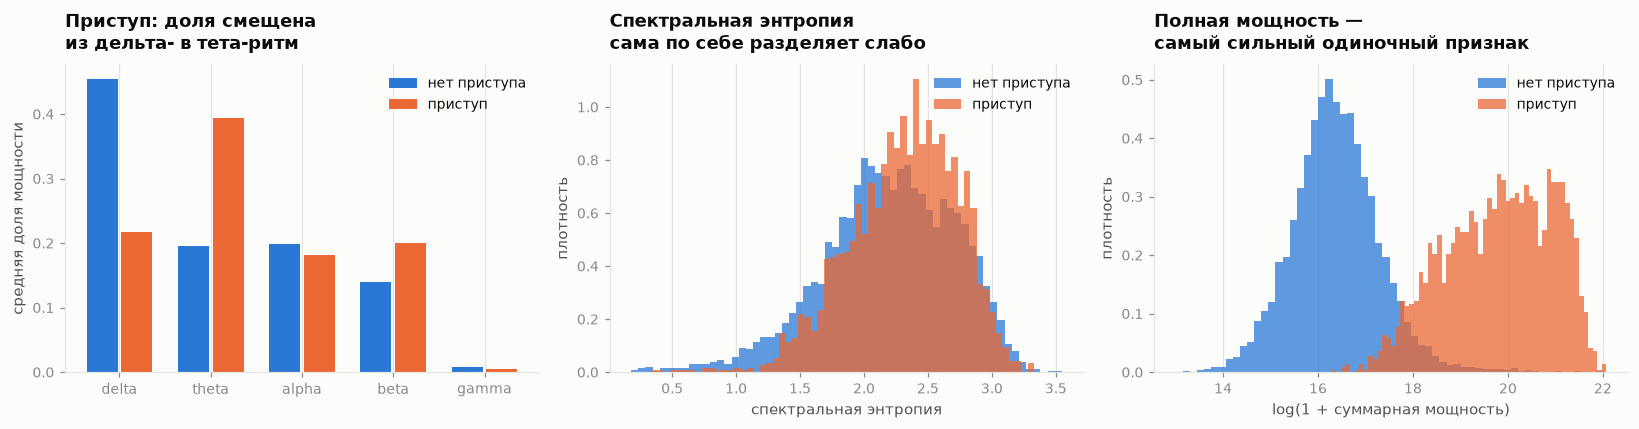

Одиночная разделяющая способность (ROC-AUC по одному признаку):
  fft_relpower_delta       приступ     0.218 | норма     0.455 | AUC 0.772
  fft_relpower_theta       приступ     0.394 | норма     0.195 | AUC 0.756
  fft_spectral_entropy     приступ     2.311 | норма     2.195 | AUC 0.564
  fft_log_total_power      приступ    19.803 | норма    16.377 | AUC 0.988


In [14]:
# Что именно различается в спектре: доли ритмов, форма спектра и полная мощность.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ["нет приступа", "приступ"]

ax = tidy(axes[0])
bands = list(EEG_BANDS)
width = 0.38
xs = np.arange(len(bands))
for k, (label, color) in enumerate(zip(labels, PALETTE[:2])):
    vals = [F_fft.loc[y == k, f"fft_relpower_{b}"].mean() for b in bands]
    ax.bar(xs + (k - 0.5) * width, vals, width=width - 0.04, color=color, label=label)
ax.set_xticks(xs); ax.set_xticklabels(bands)
ax.set_ylabel("средняя доля мощности")
ax.set_title("Приступ: доля смещена\nиз дельта- в тета-ритм")
ax.legend()

ax = tidy(axes[1])
for k, (label, color) in enumerate(zip(labels, PALETTE[:2])):
    ax.hist(F_fft.loc[y == k, "fft_spectral_entropy"], bins=60, density=True,
            color=color, alpha=0.75, label=label)
ax.set_xlabel("спектральная энтропия"); ax.set_ylabel("плотность")
ax.set_title("Спектральная энтропия\nсама по себе разделяет слабо")
ax.legend()

ax = tidy(axes[2])
for k, (label, color) in enumerate(zip(labels, PALETTE[:2])):
    ax.hist(F_fft.loc[y == k, "fft_log_total_power"], bins=60, density=True,
            color=color, alpha=0.75, label=label)
ax.set_xlabel("log(1 + суммарная мощность)"); ax.set_ylabel("плотность")
ax.set_title("Полная мощность —\nсамый сильный одиночный признак")
ax.legend()

plt.tight_layout(); plt.show()

# Проверяем утверждения на числах, а не на глаз.
print("Одиночная разделяющая способность (ROC-AUC по одному признаку):")
for feat in ["fft_relpower_delta", "fft_relpower_theta", "fft_spectral_entropy",
             "fft_log_total_power"]:
    v = F_fft[feat].to_numpy()
    print(f"  {feat:24s} приступ {v[y == 1].mean():9.3f} | норма {v[y == 0].mean():9.3f} "
          f"| AUC {max(roc_auc_score(y, v), roc_auc_score(y, -v)):.3f}")

In [15]:
X_fft = F_fft.to_numpy()
run_experiment("FFT", X_fft[idx_tr], X_fft[idx_te], feature_names=F_fft.columns.tolist())

=== FFT | признаков: 61 ===


  LogReg        ROC-AUC=0.9958  PR-AUC=0.9903  F1=0.9572  Recall=0.9478  (3 c)


  RandomForest  ROC-AUC=0.9980  PR-AUC=0.9925  F1=0.9617  Recall=0.9543  (5 c)


  LightGBM      ROC-AUC=0.9989  PR-AUC=0.9959  F1=0.9665  Recall=0.9717  (2 c)


## 7. Вейвлет-признаки (DWT)

Преобразование Фурье даёт частотный портрет, но полностью теряет информацию о том, *когда* внутри секунды что-то произошло. Дискретное вейвлет-преобразование (DWT) даёт компромисс: сигнал раскладывается на субполосы с разным частотно-временным разрешением.

Используем вейвлет **Добеши db4** и 4 уровня разложения (глубже нельзя — при 178 отсчётах и длине фильтра 8 начинаются краевые эффекты). Субполосы при частоте дискретизации 178 Гц:

| Коэффициенты | Полоса частот | Ритм ЭЭГ |
|---|---|---|
| cD1 | ~44–89 Гц | шум / высокая гамма |
| cD2 | ~22–44 Гц | гамма |
| cD3 | ~11–22 Гц | бета |
| cD4 | ~5.6–11 Гц | альфа |
| cA4 | 0–5.6 Гц | дельта / тета |

Из каждой субполосы берём набор статистик: среднее, СКО, среднее абсолютное, энергию и её долю от полной, максимум/минимум, асимметрию, эксцесс, квартили, энтропию распределения энергии и частоту переходов через ноль.

In [16]:
WAVELET = "db4"
WAVELET_LEVEL = 4


def _subband_stats(c, prefix):
    energy = (c ** 2).sum(axis=1)
    p = c ** 2 / (energy[:, None] + 1e-12)
    return {
        f"{prefix}_mean":    c.mean(axis=1),
        f"{prefix}_std":     c.std(axis=1),
        f"{prefix}_absmean": np.abs(c).mean(axis=1),
        f"{prefix}_energy":  energy,
        f"{prefix}_max":     c.max(axis=1),
        f"{prefix}_min":     c.min(axis=1),
        f"{prefix}_skew":    skew(c, axis=1),
        f"{prefix}_kurt":    kurtosis(c, axis=1),
        f"{prefix}_q25":     np.percentile(c, 25, axis=1),
        f"{prefix}_q75":     np.percentile(c, 75, axis=1),
        f"{prefix}_entropy": -(p * np.log(p + 1e-12)).sum(axis=1),
        f"{prefix}_zcr":     (np.diff(np.sign(c), axis=1) != 0).mean(axis=1),
    }


def wavelet_features(A, wavelet=WAVELET, level=WAVELET_LEVEL):
    coeffs = pywt.wavedec(A, wavelet, level=level, axis=1)
    names = [f"cA{level}"] + [f"cD{i}" for i in range(level, 0, -1)]
    total_energy = sum((c ** 2).sum(axis=1) for c in coeffs) + 1e-12

    out = {}
    for name, c in zip(names, coeffs):
        out.update(_subband_stats(c, f"wav_{name}"))
        out[f"wav_{name}_relenergy"] = (c ** 2).sum(axis=1) / total_energy
    return pd.DataFrame(out)


t0 = time.time()
F_wav = wavelet_features(X_raw)
print(f"Вейвлет-признаков: {F_wav.shape[1]} за {time.time() - t0:.1f} c")
print("Длины субполос:", [len(c[0]) for c in pywt.wavedec(X_raw[:1], WAVELET, level=WAVELET_LEVEL, axis=1)])
F_wav.iloc[:3, :8]

Вейвлет-признаков: 65 за 0.1 c
Длины субполос: [17, 17, 28, 49, 92]


,wav_cA4_mean,wav_cA4_std,wav_cA4_absmean,wav_cA4_energy,wav_cA4_max,wav_cA4_min,wav_cA4_skew,wav_cA4_kurt
0,168.657765,434.350715,379.379385,3.690802e+06,846.019372,-437.582298,0.333861,-1.459423
1,526.897609,1215.316304,1157.791397,2.982845e+07,1839.568598,-2753.187862,-1.076003,0.631153
2,-165.463089,87.466787,166.277270,5.954840e+05,6.920532,-341.228100,-0.198579,-0.366241


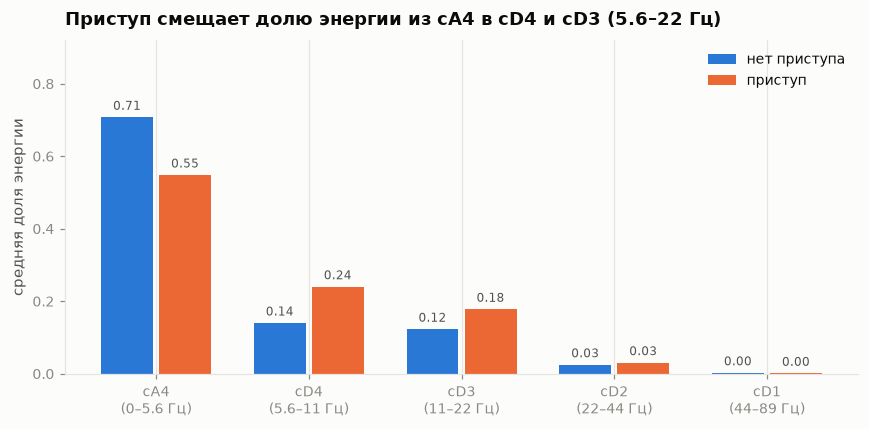

In [17]:
# Распределение относительной энергии по субполосам.
subbands = [f"cA{WAVELET_LEVEL}"] + [f"cD{i}" for i in range(WAVELET_LEVEL, 0, -1)]
fig, ax = plt.subplots(figsize=(8, 4))
tidy(ax)
xs = np.arange(len(subbands))
width = 0.38
for k, (label, color) in enumerate(zip(["нет приступа", "приступ"], PALETTE[:2])):
    vals = [F_wav.loc[y == k, f"wav_{s}_relenergy"].mean() for s in subbands]
    bars = ax.bar(xs + (k - 0.5) * width, vals, width=width - 0.04, color=color, label=label)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.012, f"{v:.2f}",
                ha="center", va="bottom", fontsize=8, color=INK_2)
ax.set_xticks(xs)
ax.set_xticklabels([f"{s}\n({r})" for s, r in
                    zip(subbands, ["0–5.6 Гц", "5.6–11 Гц", "11–22 Гц", "22–44 Гц", "44–89 Гц"])])
ax.set_ylabel("средняя доля энергии")
ax.set_ylim(0, 0.92)
ax.set_title("Приступ смещает долю энергии из cA4 в cD4 и cD3 (5.6–22 Гц)")
ax.legend()
plt.tight_layout(); plt.show()

In [18]:
X_wav = F_wav.to_numpy()
run_experiment("Wavelet", X_wav[idx_tr], X_wav[idx_te], feature_names=F_wav.columns.tolist())

=== Wavelet | признаков: 65 ===


  LogReg        ROC-AUC=0.9961  PR-AUC=0.9920  F1=0.9586  Recall=0.9565  (19 c)


  RandomForest  ROC-AUC=0.9990  PR-AUC=0.9961  F1=0.9653  Recall=0.9674  (5 c)


  LightGBM      ROC-AUC=0.9996  PR-AUC=0.9984  F1=0.9792  Recall=0.9739  (2 c)


In [19]:
# Объединяем оба сигнальных представления.
F_sig = pd.concat([F_fft, F_wav], axis=1)
X_sig = F_sig.to_numpy()
run_experiment("FFT + Wavelet", X_sig[idx_tr], X_sig[idx_te],
               feature_names=F_sig.columns.tolist())

=== FFT + Wavelet | признаков: 126 ===


  LogReg        ROC-AUC=0.9951  PR-AUC=0.9942  F1=0.9694  Recall=0.9630  (20 c)


  RandomForest  ROC-AUC=0.9994  PR-AUC=0.9975  F1=0.9749  Recall=0.9717  (7 c)


  LightGBM      ROC-AUC=0.9998  PR-AUC=0.9992  F1=0.9846  Recall=0.9761  (3 c)


**Промежуточный итог.** Спектральные и вейвлет-признаки решают главную проблему бейзлайна: логистическая регрессия из бесполезной (ROC-AUC ≈ 0.5) превращается в сильную модель. Деревья тоже растут в качестве, хотя им было хорошо и на сырых данных — они умели извлекать амплитудную информацию самостоятельно. При этом размерность снизилась со 178 признаков до 65 у вейвлетов и 61 у FFT.

Обе группы признаков описывают одно и то же явление с разных сторон и согласуются между собой: приступ — это резкий рост абсолютной мощности с перераспределением доли энергии из самой низкой полосы (дельта / cA4) в полосу 4–22 Гц (тета-бета / cD4-cD3).

## 8. Автоматическая генерация признаков: tsfresh

`tsfresh` — библиотека автоматического извлечения признаков из временных рядов. Она считает несколько сотен характеристик: моменты распределения, автокорреляции, параметры авторегрессии, энтропии (approximate, sample, binned), количество пиков, коэффициенты непрерывного вейвлет-преобразования, FFT-коэффициенты и агрегаты, тесты стационарности, характеристики линейного тренда и др.

Используем профиль `EfficientFCParameters` — весь набор без самых дорогих по времени функций.

Порядок работы и защита от утечки:

1. перевести данные в «длинный» формат (`id`, `time`, `value`);
2. извлечь признаки — каждый ряд обрабатывается независимо от остальных, поэтому считать сразу по всей выборке безопасно;
3. заполнить NaN/±inf (часть признаков не определена для некоторых рядов) — **медианы и границы берём только по train** и применяем их к тесту: обычный `impute()` по всей таблице подставил бы в train значения, посчитанные с участием теста;
4. **отобрать признаки тестами значимости строго по train** (`select_features`) — здесь утечка была бы самой грубой, так как используются метки.

In [20]:
from tsfresh import extract_features, select_features
from tsfresh.feature_extraction import EfficientFCParameters
from tsfresh.utilities.dataframe_functions import (
    get_range_values_per_column, impute_dataframe_range,
)

n_series, n_steps = X_raw.shape
long_df = pd.DataFrame({
    "id":    np.repeat(np.arange(n_series), n_steps),
    "time":  np.tile(np.arange(n_steps), n_series),
    "value": X_raw.ravel(),
})
print("Длинный формат:", long_df.shape)
long_df.head()

Длинный формат: (2047000, 3)


,id,time,value
0,0,0,135.0
1,0,1,190.0
2,0,2,229.0
3,0,3,223.0
4,0,4,192.0


In [21]:
t0 = time.time()
F_tsf_extracted = extract_features(
    long_df,
    column_id="id", column_sort="time", column_value="value",
    default_fc_parameters=EfficientFCParameters(),
    n_jobs=8, disable_progressbar=True,
).sort_index()
print(f"\ntsfresh сгенерировал {F_tsf_extracted.shape[1]} признаков за {time.time() - t0:.0f} c")
print("Признаков с пропусками/бесконечностями:",
      int((~np.isfinite(F_tsf_extracted.to_numpy(dtype=float))).any(axis=0).sum()))

# Границы для заполнения считаем ТОЛЬКО по train и применяем ко всей выборке.
col_max, col_min, col_median = get_range_values_per_column(F_tsf_extracted.iloc[idx_tr])
F_tsf_imputed = impute_dataframe_range(F_tsf_extracted.copy(), col_max, col_min, col_median)
print("Пропусков после импутации:", int(F_tsf_imputed.isna().sum().sum()))


tsfresh сгенерировал 777 признаков за 106 c
Признаков с пропусками/бесконечностями: 46


Пропусков после импутации: 0


In [22]:
# Отбор значимых признаков — только по train.
F_tr = F_tsf_imputed.iloc[idx_tr]
t0 = time.time()
tsf_cols = select_features(F_tr, pd.Series(y_tr, index=F_tr.index),
                           n_jobs=8).columns.tolist()
print(f"Отобрано {len(tsf_cols)} из {F_tsf_imputed.shape[1]} признаков за {time.time() - t0:.1f} c")

F_tsf = F_tsf_imputed[tsf_cols]
X_tsf = F_tsf.to_numpy()
print("\nПримеры отобранных признаков:")
for c in tsf_cols[:10]:
    print("  ", c)

Отобрано 353 из 777 признаков за 0.9 c

Примеры отобранных признаков:
   value__abs_energy
   value__mean_abs_change
   value__number_peaks__n_1
   value__agg_linear_trend__attr_"stderr"__chunk_len_10__f_agg_"min"
   value__agg_linear_trend__attr_"stderr"__chunk_len_5__f_agg_"var"
   value__agg_linear_trend__attr_"stderr"__chunk_len_5__f_agg_"mean"
   value__agg_linear_trend__attr_"stderr"__chunk_len_5__f_agg_"min"
   value__agg_linear_trend__attr_"stderr"__chunk_len_5__f_agg_"max"
   value__agg_linear_trend__attr_"stderr"__chunk_len_10__f_agg_"mean"
   value__agg_linear_trend__attr_"stderr"__chunk_len_10__f_agg_"max"


In [23]:
run_experiment("tsfresh", X_tsf[idx_tr], X_tsf[idx_te], feature_names=tsf_cols)

=== tsfresh | признаков: 353 ===


  LogReg        ROC-AUC=0.9985  PR-AUC=0.9954  F1=0.9690  Recall=0.9522  (21 c)


  RandomForest  ROC-AUC=0.9993  PR-AUC=0.9973  F1=0.9802  Recall=0.9696  (12 c)


  LightGBM      ROC-AUC=0.9998  PR-AUC=0.9994  F1=0.9901  Recall=0.9826  (9 c)


In [24]:
# Объединённый набор: ручные сигнальные признаки + автоматические.
F_all = pd.concat([F_sig.reset_index(drop=True), F_tsf.reset_index(drop=True)], axis=1)
X_all = F_all.to_numpy()
run_experiment("FFT + Wavelet + tsfresh", X_all[idx_tr], X_all[idx_te],
               feature_names=F_all.columns.tolist())

=== FFT + Wavelet + tsfresh | признаков: 479 ===


  LogReg        ROC-AUC=0.9973  PR-AUC=0.9951  F1=0.9760  Recall=0.9739  (20 c)


  RandomForest  ROC-AUC=0.9994  PR-AUC=0.9978  F1=0.9815  Recall=0.9804  (14 c)


  LightGBM      ROC-AUC=0.9999  PR-AUC=0.9995  F1=0.9891  Recall=0.9826  (12 c)


## 9. Сравнение результатов

In [25]:
res = results_table(sort_by="F1")
res

,Признаки,Модель,n_features,CV ROC-AUC,CV F1,ROC-AUC,PR-AUC,F1,Precision,Recall,BalAcc
0,tsfresh,LightGBM,353,0.9995,0.9814,0.9998,0.9994,0.9901,0.9978,0.9826,0.9910
1,FFT + Wavelet + tsfresh,LightGBM,479,0.9996,0.9853,0.9999,0.9995,0.9891,0.9956,0.9826,0.9908
2,FFT + Wavelet,LightGBM,126,0.9996,0.9806,0.9998,0.9992,0.9846,0.9934,0.9761,0.9872
3,FFT + Wavelet + tsfresh,RandomForest,479,0.9991,0.9732,0.9994,0.9978,0.9815,0.9826,0.9804,0.9880
4,tsfresh,RandomForest,353,0.9990,0.9726,0.9993,0.9973,0.9802,0.9911,0.9696,0.9837
5,Wavelet,LightGBM,65,0.9993,0.9736,0.9996,0.9984,0.9792,0.9846,0.9739,0.9851
6,FFT + Wavelet + tsfresh,LogReg,479,0.9970,0.9727,0.9973,0.9951,0.9760,0.9782,0.9739,0.9842
7,FFT + Wavelet,RandomForest,126,0.9990,0.9707,0.9994,0.9975,0.9749,0.9781,0.9717,0.9832
8,FFT + Wavelet,LogReg,126,0.9983,0.9702,0.9951,0.9942,0.9694,0.9758,0.9630,0.9785
9,tsfresh,LogReg,353,0.9970,0.9677,0.9985,0.9954,0.9690,0.9865,0.9522,0.9745


In [26]:
# Сводка по лучшей модели в каждом наборе признаков.
best_per_fs = (pd.DataFrame(RESULTS)
               .sort_values("F1", ascending=False)
               .groupby("Признаки", as_index=False).first()
               [["Признаки", "Модель", "n_features", "ROC-AUC", "PR-AUC", "F1", "Precision", "Recall"]]
               .sort_values("F1", ascending=False)
               .reset_index(drop=True)
               .round(4))
best_per_fs

,Признаки,Модель,n_features,ROC-AUC,PR-AUC,F1,Precision,Recall
0,tsfresh,LightGBM,353,0.9998,0.9994,0.9901,0.9978,0.9826
1,FFT + Wavelet + tsfresh,LightGBM,479,0.9999,0.9995,0.9891,0.9956,0.9826
2,FFT + Wavelet,LightGBM,126,0.9998,0.9992,0.9846,0.9934,0.9761
3,Wavelet,LightGBM,65,0.9996,0.9984,0.9792,0.9846,0.9739
4,FFT,LightGBM,61,0.9989,0.9959,0.9665,0.9613,0.9717
5,Сырой сигнал (178),LightGBM,178,0.9973,0.9898,0.9540,0.9604,0.9478


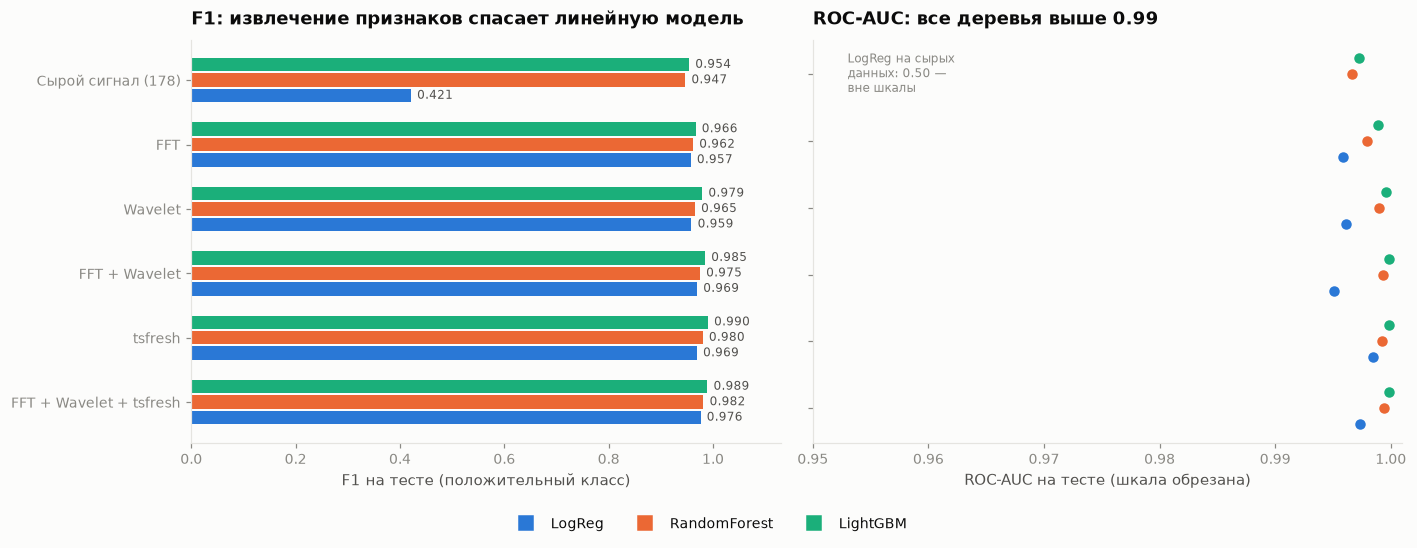

In [27]:
res_df = pd.DataFrame(RESULTS)
fs_order = ["Сырой сигнал (178)", "FFT", "Wavelet", "FFT + Wavelet",
            "tsfresh", "FFT + Wavelet + tsfresh"]
models_order = ["LogReg", "RandomForest", "LightGBM"]
model_color = dict(zip(models_order, PALETTE[:3]))   # цвет закреплён за моделью

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Слева — F1 столбиками (есть нулевая база, разброс большой).
ax = tidy(axes[0], xgrid=True)
h = 0.24
for k, m in enumerate(models_order):
    vals = [res_df[(res_df["Признаки"] == f) & (res_df["Модель"] == m)]["F1"].iloc[0]
            for f in fs_order]
    ypos = np.arange(len(fs_order)) - (k - 1) * h
    ax.barh(ypos, vals, height=h - 0.03, color=model_color[m], label=m)
    for yy, v in zip(ypos, vals):
        ax.text(v + 0.012, yy, f"{v:.3f}", va="center", fontsize=8, color=INK_2)
ax.set_yticks(np.arange(len(fs_order))); ax.set_yticklabels(fs_order)
ax.invert_yaxis()
ax.set_xlim(0, 1.13); ax.set_xlabel("F1 на тесте (положительный класс)")
ax.set_title("F1: извлечение признаков спасает линейную модель")

# Справа — ROC-AUC точками: значения близки к 1, столбики от нуля были бы нечитаемы.
ax = tidy(axes[1], xgrid=True)
for k, m in enumerate(models_order):
    vals = [res_df[(res_df["Признаки"] == f) & (res_df["Модель"] == m)]["ROC-AUC"].iloc[0]
            for f in fs_order]
    ypos = np.arange(len(fs_order)) - (k - 1) * h
    ax.scatter(vals, ypos, s=70, color=model_color[m], label=m, zorder=3,
               edgecolors=SURFACE, linewidths=1.5)
ax.set_yticks(np.arange(len(fs_order))); ax.set_yticklabels([])
ax.invert_yaxis()
ax.set_xlim(0.95, 1.001); ax.set_xlabel("ROC-AUC на тесте (шкала обрезана)")
ax.set_title("ROC-AUC: все деревья выше 0.99")
ax.annotate("LogReg на сырых\nданных: 0.50 —\nвне шкалы",
            xy=(0.953, 0.0), fontsize=8, color=INK_MUTED, va="center")

# Одна легенда на обе панели — цвет закреплён за моделью в обеих.
handles = [plt.Line2D([], [], marker="s", markersize=9, linestyle="",
                      color=model_color[m], label=m) for m in models_order]
fig.legend(handles=handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, 0.0))

plt.tight_layout(rect=[0, 0.07, 1, 1]); plt.show()

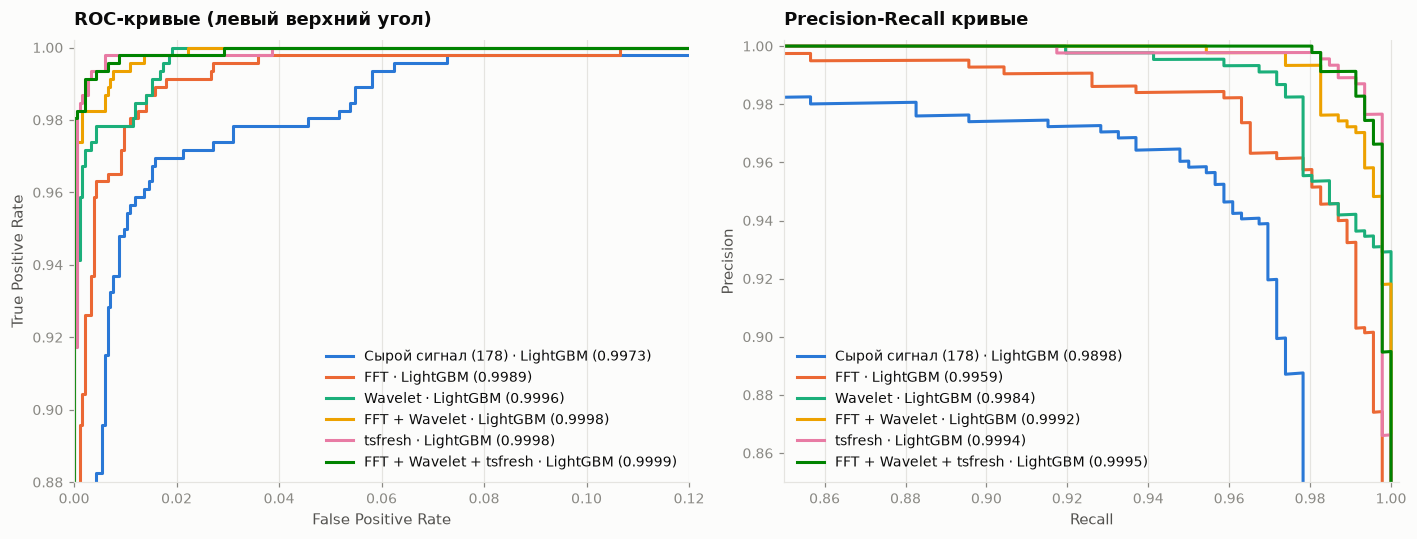

In [28]:
# ROC и PR кривые лучшей модели каждого набора признаков (масштаб укрупнён).
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
best_rows = (pd.DataFrame(RESULTS).sort_values("F1", ascending=False)
             .groupby("Признаки", as_index=False).first())
order = [f for f in fs_order if f in set(best_rows["Признаки"])]

ax = tidy(axes[0])
for i, fs_name in enumerate(order):
    mname = best_rows.loc[best_rows["Признаки"] == fs_name, "Модель"].iloc[0]
    proba = PREDS[(fs_name, mname)]
    fpr, tpr, _ = roc_curve(y_te, proba)
    ax.plot(fpr, tpr, color=PALETTE[i], label=f"{fs_name} · {mname} ({roc_auc_score(y_te, proba):.4f})")
ax.plot([0, 1], [0, 1], color=INK_MUTED, linewidth=1, linestyle=":")
ax.set_xlim(0, 0.12); ax.set_ylim(0.88, 1.002)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC-кривые (левый верхний угол)")
ax.legend(loc="lower right")

ax = tidy(axes[1])
for i, fs_name in enumerate(order):
    mname = best_rows.loc[best_rows["Признаки"] == fs_name, "Модель"].iloc[0]
    proba = PREDS[(fs_name, mname)]
    prec, rec, _ = precision_recall_curve(y_te, proba)
    ax.plot(rec, prec, color=PALETTE[i],
            label=f"{fs_name} · {mname} ({average_precision_score(y_te, proba):.4f})")
ax.axhline(y_te.mean(), color=INK_MUTED, linewidth=1, linestyle=":")
ax.set_xlim(0.85, 1.002); ax.set_ylim(0.85, 1.002)
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall кривые")
ax.legend(loc="lower left")

plt.tight_layout(); plt.show()

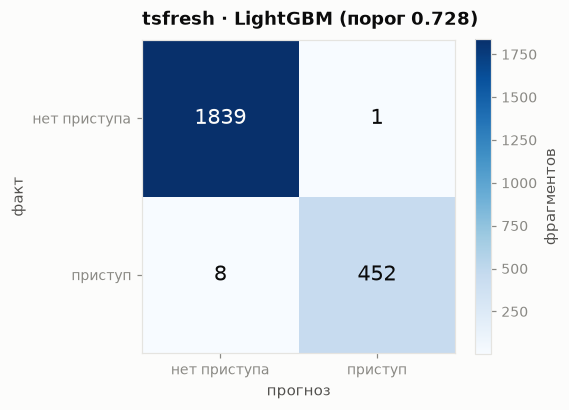

              precision    recall  f1-score   support

нет приступа     0.9957    0.9995    0.9976      1840
     приступ     0.9978    0.9826    0.9901       460

    accuracy                         0.9961      2300
   macro avg     0.9967    0.9910    0.9939      2300
weighted avg     0.9961    0.9961    0.9961      2300

Пропущенных приступов (FN): 8 из 460   |   Ложных тревог (FP): 1 из 1840


In [29]:
# Матрица ошибок и отчёт для лучшей конфигурации.
best = pd.DataFrame(RESULTS).sort_values("F1", ascending=False).iloc[0]
BEST_KEY = (best["Признаки"], best["Модель"])
best_proba = PREDS[BEST_KEY]
best_pred = (best_proba >= best["thr"]).astype(int)

cm = confusion_matrix(y_te, best_pred)
fig, ax = plt.subplots(figsize=(5.2, 4.4))
im = ax.imshow(cm, cmap="Blues")          # последовательная шкала: один тон, светлый -> тёмный
ax.set_xticks([0, 1], labels=["нет приступа", "приступ"])
ax.set_yticks([0, 1], labels=["нет приступа", "приступ"])
ax.set_xlabel("прогноз"); ax.set_ylabel("факт")
ax.set_title(f"{BEST_KEY[0]} · {BEST_KEY[1]} (порог {best['thr']:.3f})")
ax.grid(False)
vmax = cm.max()
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]}", ha="center", va="center", fontsize=14,
                color=SURFACE if cm[i, j] > vmax * 0.5 else INK)
plt.colorbar(im, ax=ax, shrink=0.8, label="фрагментов")
plt.tight_layout(); plt.show()

print(classification_report(y_te, best_pred,
                            target_names=["нет приступа", "приступ"], digits=4))
tn, fp, fn, tp = cm.ravel()
print(f"Пропущенных приступов (FN): {fn} из {tp + fn}   |   Ложных тревог (FP): {fp} из {tn + fp}")

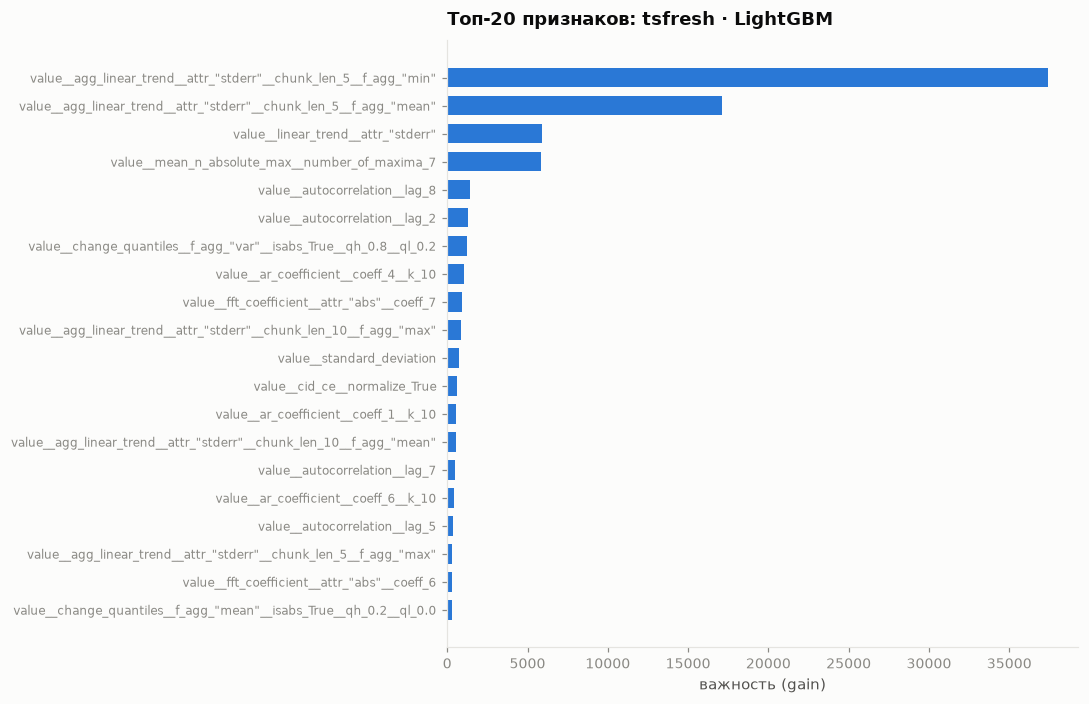

In [30]:
# Какие признаки оказались важнее всего у лучшей древесной модели.
model, fnames = MODELS[BEST_KEY]
if hasattr(model, "booster_"):
    gain = model.booster_.feature_importance(importance_type="gain")
    imp_label = "важность (gain)"
elif hasattr(model, "feature_importances_"):
    gain = model.feature_importances_
    imp_label = "важность (impurity)"
else:
    gain = np.abs(model[-1].coef_.ravel())     # Pipeline с линейной моделью
    imp_label = "|коэффициент| (после стандартизации)"

imp = (pd.DataFrame({"feature": fnames, "importance": gain})
       .sort_values("importance", ascending=False).head(20).iloc[::-1])

fig, ax = plt.subplots(figsize=(10, 6.5))
tidy(ax, xgrid=True)
ax.barh(np.arange(len(imp)), imp["importance"], color=PALETTE[0], height=0.7)
ax.set_yticks(np.arange(len(imp)))
ax.set_yticklabels([f[:70] for f in imp["feature"]], fontsize=8)
ax.set_xlabel(imp_label)
ax.set_title(f"Топ-20 признаков: {BEST_KEY[0]} · {BEST_KEY[1]}")
plt.tight_layout(); plt.show()

## 10. Проверка на утечку: разбиение по записям

Вернёмся к наблюдению из раздела 1.1: при случайном разбиении 23 фрагмента одной записи попадают и в train, и в test. Проверим, влияет ли это на оценку: разобьём **по записям** (все 23 фрагмента одной записи целиком попадают в одну часть), сохранив стратификацию по классу на уровне записей, и обучим ту же модель на тех же признаках.

Чтобы сравнение было корректным, при разбиении по записям пересобираем всё, что зависит от меток обучающей части:

* признаки tsfresh **переотбираем** на train этого разбиения — иначе отбор, сделанный по случайному train, «подсматривал» бы метки записей, попавших в group-test;
* порог подбираем по out-of-fold прогнозам внутри train, причём для разбиения по записям используем `StratifiedGroupKFold`, чтобы и внутри кросс-валидации записи не пересекались.

In [31]:
rec_labels = np.unique(groups)
rec_class = df.groupby(recording)["y"].first().reindex(rec_labels).to_numpy()
rec_y = (rec_class == 1).astype(int)

rec_tr, rec_te = train_test_split(rec_labels, test_size=0.2,
                                  stratify=rec_y, random_state=SEED)
mask_tr = np.isin(groups, rec_tr)
mask_te = np.isin(groups, rec_te)
g_idx_tr, g_idx_te = np.where(mask_tr)[0], np.where(mask_te)[0]
g_y_tr, g_y_te = y[g_idx_tr], y[g_idx_te]

print(f"Записей: train {len(rec_tr)}, test {len(rec_te)}")
print(f"Фрагментов: train {len(g_idx_tr)}, test {len(g_idx_te)}")
print(f"Доля приступов: train {g_y_tr.mean():.3f}, test {g_y_te.mean():.3f}")
print("Пересечение записей между train и test:", len(set(rec_tr) & set(rec_te)))

Записей: train 400, test 100
Фрагментов: train 9200, test 2300
Доля приступов: train 0.200, test 0.200
Пересечение записей между train и test: 0


In [32]:
# Сравниваем одну и ту же модель на одних и тех же признаках при двух схемах разбиения.
from sklearn.model_selection import StratifiedGroupKFold


def lgbm():
    return LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=31,
                          subsample=0.9, subsample_freq=1, colsample_bytree=0.8,
                          n_jobs=N_JOBS, random_state=SEED, verbose=-1)


splits = {
    "Случайное (по фрагментам)": (idx_tr, idx_te, CV),
    "По записям (без утечки)":   (g_idx_tr, g_idx_te,
                                  StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)),
}

comparison = []
for fs_name in ["FFT + Wavelet", "tsfresh"]:
    for split_name, (a, b, cv) in splits.items():
        if fs_name == "tsfresh":
            # Переотбор признаков на train соответствующего разбиения.
            sub_tr = F_tsf_imputed.iloc[a]
            cols = select_features(sub_tr, pd.Series(y[a], index=sub_tr.index),
                                   n_jobs=8).columns.tolist()
            Xmat = F_tsf_imputed[cols].to_numpy()
            n_feat = len(cols)
        else:
            Xmat, n_feat = X_sig, X_sig.shape[1]

        ya, yb = y[a], y[b]
        oof = cross_val_predict(lgbm(), Xmat[a], ya, groups=groups[a], cv=cv,
                                method="predict_proba", n_jobs=1)[:, 1]
        thr = best_f1_threshold(ya, oof)

        model = lgbm().fit(Xmat[a], ya)
        proba = model.predict_proba(Xmat[b])[:, 1]
        pred = (proba >= thr).astype(int)

        comparison.append({
            "Признаки": fs_name, "Разбиение": split_name, "n_features": n_feat,
            "ROC-AUC": roc_auc_score(yb, proba),
            "PR-AUC": average_precision_score(yb, proba),
            "F1": f1_score(yb, pred),
            "Precision": precision_score(yb, pred),
            "Recall": recall_score(yb, pred),
            "порог": thr,
        })

cmp_df = pd.DataFrame(comparison).round(4)
cmp_df

,Признаки,Разбиение,n_features,ROC-AUC,PR-AUC,F1,Precision,Recall,порог
0,FFT + Wavelet,Случайное (по фрагментам),126,0.9998,0.9992,0.9846,0.9934,0.9761,0.7342
1,FFT + Wavelet,По записям (без утечки),126,1.0000,0.9998,0.9766,0.9544,1.0000,0.3607
2,tsfresh,Случайное (по фрагментам),353,0.9998,0.9994,0.9901,0.9978,0.9826,0.7282
3,tsfresh,По записям (без утечки),336,0.9999,0.9995,0.9787,0.9583,1.0000,0.4813


## 11. Выводы

### 11.1. Что было сделано

Построен и сравнён полный цикл детектирования эпилептического приступа по односекундным фрагментам ЭЭГ: EDA → бинаризация цели → стратифицированное разбиение 80/20 → шесть наборов признаков × три модели, с единым протоколом (5-фолдовая кросс-валидация на train, подбор порога по out-of-fold прогнозам, финальная оценка на отложенных 2300 фрагментах).

### 11.2. Итоговое качество

Лучшая модель в каждом наборе признаков (везде это **LightGBM**):

| Набор признаков | Признаков | ROC-AUC | PR-AUC | F1 | Precision | Recall |
|---|---:|---:|---:|---:|---:|---:|
| Сырой сигнал | 178 | 0.9973 | 0.9898 | 0.9540 | 0.9604 | 0.9478 |
| FFT | 61 | 0.9989 | 0.9959 | 0.9665 | 0.9613 | 0.9717 |
| Wavelet | 65 | 0.9996 | 0.9984 | 0.9792 | 0.9846 | 0.9739 |
| FFT + Wavelet | 126 | 0.9998 | 0.9992 | 0.9846 | 0.9934 | 0.9761 |
| **tsfresh** | **353** | **0.9998** | **0.9994** | **0.9901** | **0.9978** | **0.9826** |
| FFT + Wavelet + tsfresh | 479 | 0.9999 | 0.9995 | 0.9891 | 0.9956 | 0.9826 |

Лучшая конфигурация (tsfresh + LightGBM) ошибается на тесте 9 раз из 2300: **8 пропущенных приступов** из 460 и **1 ложная тревога** из 1840. Разрыв между тремя верхними строками — 1–2 фрагмента, то есть в пределах шума; содержательно различаются только бейзлайн, FFT и всё остальное.

### 11.3. Главный вывод: извлечение признаков важнее выбора модели

Ключевой результат эксперимента — не рост F1 у бустинга, а поведение **логистической регрессии**:

| Признаки | ROC-AUC LogReg | F1 LogReg |
|---|---:|---:|
| Сырой сигнал | **0.4993** | 0.4209 |
| FFT | 0.9958 | 0.9572 |
| Wavelet | 0.9961 | 0.9586 |
| tsfresh | 0.9985 | 0.9690 |
| FFT + Wavelet + tsfresh | 0.9973 | 0.9760 |

На сырых отсчётах линейная модель работает **на уровне подбрасывания монеты**. Причина содержательная: признак «амплитуда на 37-м отсчёте» не имеет устойчивого смысла — фаза сигнала внутри секунды произвольна, среднее значение около нуля в обоих классах, поэтому никакая взвешенная сумма отсчётов классы не разделяет. Стоит перейти к признакам, инвариантным к сдвигу по времени (энергия, спектральные полосы, статистики субполос), — и та же самая модель без единого изменения гиперпараметров даёт ROC-AUC ≈ 0.996.

Деревья же на сырых данных работали хорошо (ROC-AUC 0.997) именно потому, что своими порогами по отдельным отсчётам неявно реконструируют «была ли где-то большая амплитуда», то есть сами делают грубое извлечение признаков. Извлечение признаков вручную превращает эту неявную работу в явную, и качество растёт ещё выше при меньшей размерности: 65 вейвлет-признаков дают F1 0.979 против 0.954 у 178 сырых отсчётов.

**Практический смысл:** ошибка «подали сырой временной ряд в линейную модель и решили, что задача нерешаема» здесь стоила бы всего результата.

### 11.4. Что именно отличает приступ (физическая картина)

Проверка признаков по отдельности (ROC-AUC по одному признаку) дала неожиданную по сравнению с «учебной» интуицией картину:

| Признак | Приступ | Норма | AUC |
|---|---:|---:|---:|
| log(суммарная мощность) | 19.80 | 16.38 | **0.988** |
| доля мощности в дельта (0.5–4 Гц) | 0.218 | 0.455 | 0.772 |
| доля мощности в тета (4–8 Гц) | 0.394 | 0.195 | 0.756 |
| спектральная энтропия | 2.311 | 2.195 | 0.564 |

* Решает задачу прежде всего **абсолютная мощность**: один этот признак даёт AUC 0.988. Амплитуда во время приступа выше в 5–6 раз по медиане (std 277 мкВ против 38–55 мкВ), а спектральная плотность — в среднем в 40 раз ниже 10 Гц.
* **Относительное** распределение энергии смещается не в дельта-, а в **тета-диапазон**: доля дельта во время приступа не растёт, а падает (0.218 против 0.455). Вейвлет-разложение показывает то же самое независимо: доля энергии уходит из cA4 (0–5.6 Гц) в cD4 и cD3 (5.6–22 Гц).
* **Спектральная энтропия оказалась почти бесполезна** (AUC 0.564) и вдобавок ведёт себя противоположно ожидаемому: во время приступа она чуть *выше*, а не ниже. Учебное правило «синхронная активность → более острый спектр → низкая энтропия» здесь не работает, потому что мощность приступа поднимается широкой полосой, а не одним пиком, и нормированный спектр не становится острее. Полезное напоминание: интуитивные признаки нужно проверять на данных, а не принимать на веру.

### 11.5. Сравнение методов извлечения признаков

* **FFT (61 признак).** Даёт скачок относительно бейзлайна и хорошо интерпретируется, но в одиночку — самый слабый из методов извлечения (F1 0.967). Усреднение по всей секунде теряет информацию о том, когда именно произошёл всплеск.
* **Wavelet DWT db4 (65 признаков).** При сопоставимом бюджете признаков заметно **обходит FFT** (F1 0.979 против 0.967). Разумно: вейвлеты сохраняют частотно-временную локализацию, а приступ — это всплеск, который может занимать не всю секунду.
* **FFT + Wavelet (126 признаков).** Представления дополняют друг друга: F1 0.985 — больше, чем у каждого по отдельности. Лучшее соотношение «качество / стоимость»: признаки считаются за 0.3 секунды, обучение — за 3 секунды.
* **tsfresh (777 → 353 признака).** Лучший результат (F1 0.990), причём «вслепую», без знаний о предметной области. В отобранные признаки попали ровно те же по смыслу характеристики, которые мы конструировали руками: `abs_energy`, `mean_abs_change`, FFT-агрегаты, коэффициенты непрерывного вейвлет-преобразования. Цена — 123 секунды на извлечение (против 0.3 с) и слабо интерпретируемые имена признаков.
* **Объединение всего (479 признаков).** Лучший ROC-AUC (0.9999), но по F1 (0.9891) оно на 1 ошибку *хуже* одного tsfresh. Прирост от объединения исчерпан — сигнал в наборах один и тот же.

**Рекомендация.** Если нужна интерпретируемость и скорость — **FFT + Wavelet + LightGBM** (F1 0.985 при 126 признаках, весь цикл — секунды). Если задача новая и предметных знаний нет — tsfresh как быстрый способ нащупать потолок качества, а затем замена отобранных признаков на ручные аналоги.

### 11.6. Проверка на утечку данных

При разборе идентификаторов выяснилось, что 11500 фрагментов — это **500 записей по 23 односекундных фрагмента**, причём все фрагменты одной записи принадлежат одному пациенту и одному классу. Случайное разбиение (требуемое заданием) раскидывает фрагменты одной записи между train и test, и модель в принципе могла бы «узнавать пациента» вместо приступа.

Мы это проверили прямым экспериментом — разбиением по записям с нулевым пересечением пациентов, с переотбором признаков tsfresh на новом train и подбором порога через `StratifiedGroupKFold`:

| Признаки | Разбиение | ROC-AUC | PR-AUC | F1 | Precision | Recall |
|---|---|---:|---:|---:|---:|---:|
| FFT + Wavelet | случайное | 0.9998 | 0.9992 | 0.9846 | 0.9934 | 0.9761 |
| FFT + Wavelet | по записям | 1.0000 | 0.9998 | 0.9766 | 0.9544 | 1.0000 |
| tsfresh | случайное | 0.9998 | 0.9994 | 0.9901 | 0.9978 | 0.9826 |
| tsfresh | по записям | 0.9999 | 0.9995 | 0.9787 | 0.9583 | 1.0000 |

**Опасение не подтвердилось.** При честном разбиении по пациентам ранжирующее качество не падает вовсе: ROC-AUC и PR-AUC даже чуть выше, recall достигает 1.0 (ни одного пропущенного приступа). F1 снижается на ~1 пункт исключительно за счёт precision — порог, подобранный на train, при смене состава пациентов оказывается чуть смещённым, и растёт число ложных тревог. То есть высокие метрики объясняются не утечкой, а тем, что паттерн приступа универсален и не зависит от конкретного пациента; от пациента зависит лишь **калибровка порога**.

Практический вывод: при внедрении на новых пациентах ранжирование можно переносить как есть, а порог нужно перекалибровать. И в любом случае структуру данных следует проверять заранее — в задачах с большей межпациентной вариабельностью расхождение между двумя схемами разбиения бывает драматическим.

### 11.7. Замечания о методике и ограничения

* **Дисбаланс.** После бинаризации классы распределены 20/80, поэтому accuracy неинформативна (константный прогноз даёт 80%). Опирались на ROC-AUC, PR-AUC и F1 по положительному классу. Порог подбирался по out-of-fold прогнозам, а не брался равным 0.5: на бейзлайне это меняет F1 логистической регрессии с 0.15 до 0.42.
* **Защита от утечки.** Признаки tsfresh считаются для каждого ряда независимо, поэтому извлечение на всей выборке безопасно, а вот заполнение пропусков и отбор признаков выполнены строго по train (`get_range_values_per_column` на train + `impute_dataframe_range`, `select_features` на train). Обычный `impute()` по всей таблице подставил бы в обучающую часть медианы, посчитанные с участием теста.
* **Цена ошибок.** В медицинском приложении пропуск приступа опаснее ложной тревоги. Порог под F1 балансирует precision и recall, но при внедрении его следует сдвигать в сторону recall — раздел 11.6 показывает, что recall 1.0 достигается при precision около 0.95.
* **Задача «лёгкая».** Приступ отличается амплитудой в 5–6 раз, поэтому все разумные методы дают ROC-AUC выше 0.99, и различать их приходится по F1 и PR-AUC. Настоящая сложность клинической задачи — раннее детектирование (предиктивные паттерны до начала приступа) и отделение приступа от артефактов движения, чего в этих данных нет.
* **Гиперпараметры намеренно не подбирались:** цель сравнения — влияние **признаков**, а не тюнинга. С учётом 9 ошибок из 2300 запас для роста минимален, и дальнейшая оптимизация упрётся в шум разметки.